Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)   

Load and Inspect

In [6]:
df = pd.read_csv("../data/salary_data.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nMissing values:\n{df.isnull().sum()}")   

Shape: (250000, 10)

Columns: ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary']

Dtypes:
job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object

First 5 rows:
            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  s

Target Variable (salary)

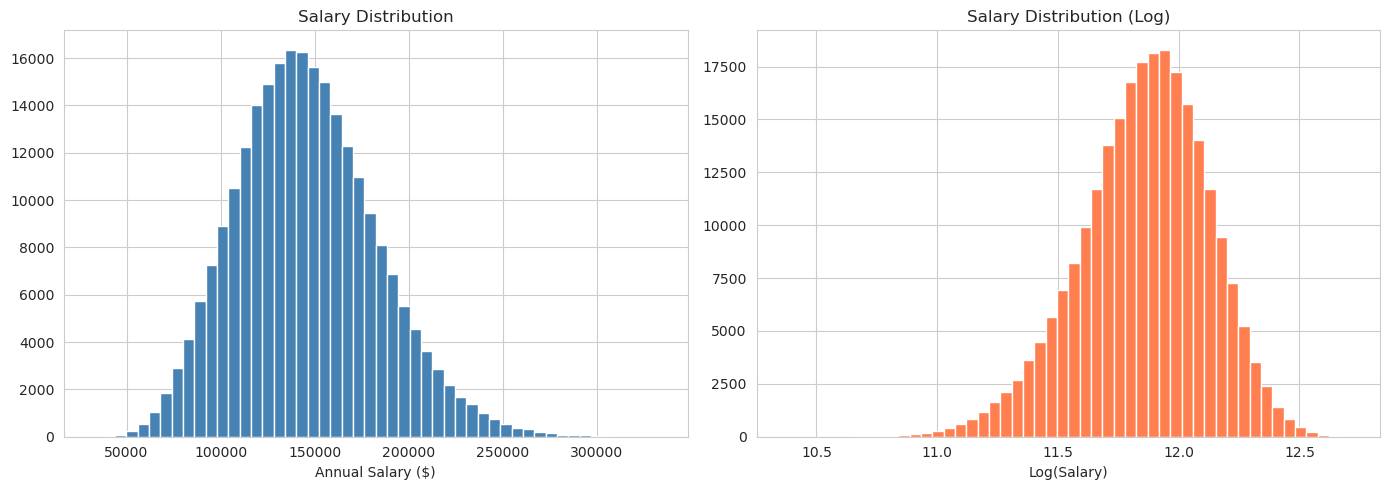

Mean: $145,718
Median: $143,453
Skewness: 0.38


In [7]:
# Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['salary'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Salary Distribution')
axes[0].set_xlabel('Annual Salary ($)')

# Log transform (salaries are usually right-skewed)
df['salary_log'] = np.log1p(df['salary'])
axes[1].hist(df['salary_log'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Salary Distribution (Log)')
axes[1].set_xlabel('Log(Salary)')

plt.tight_layout()
plt.show()

print(f"Mean: ${df['salary'].mean():,.0f}")
print(f"Median: ${df['salary'].median():,.0f}")
print(f"Skewness: {df['salary'].skew():.2f}")   

Categorical Features

Categorical columns: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']


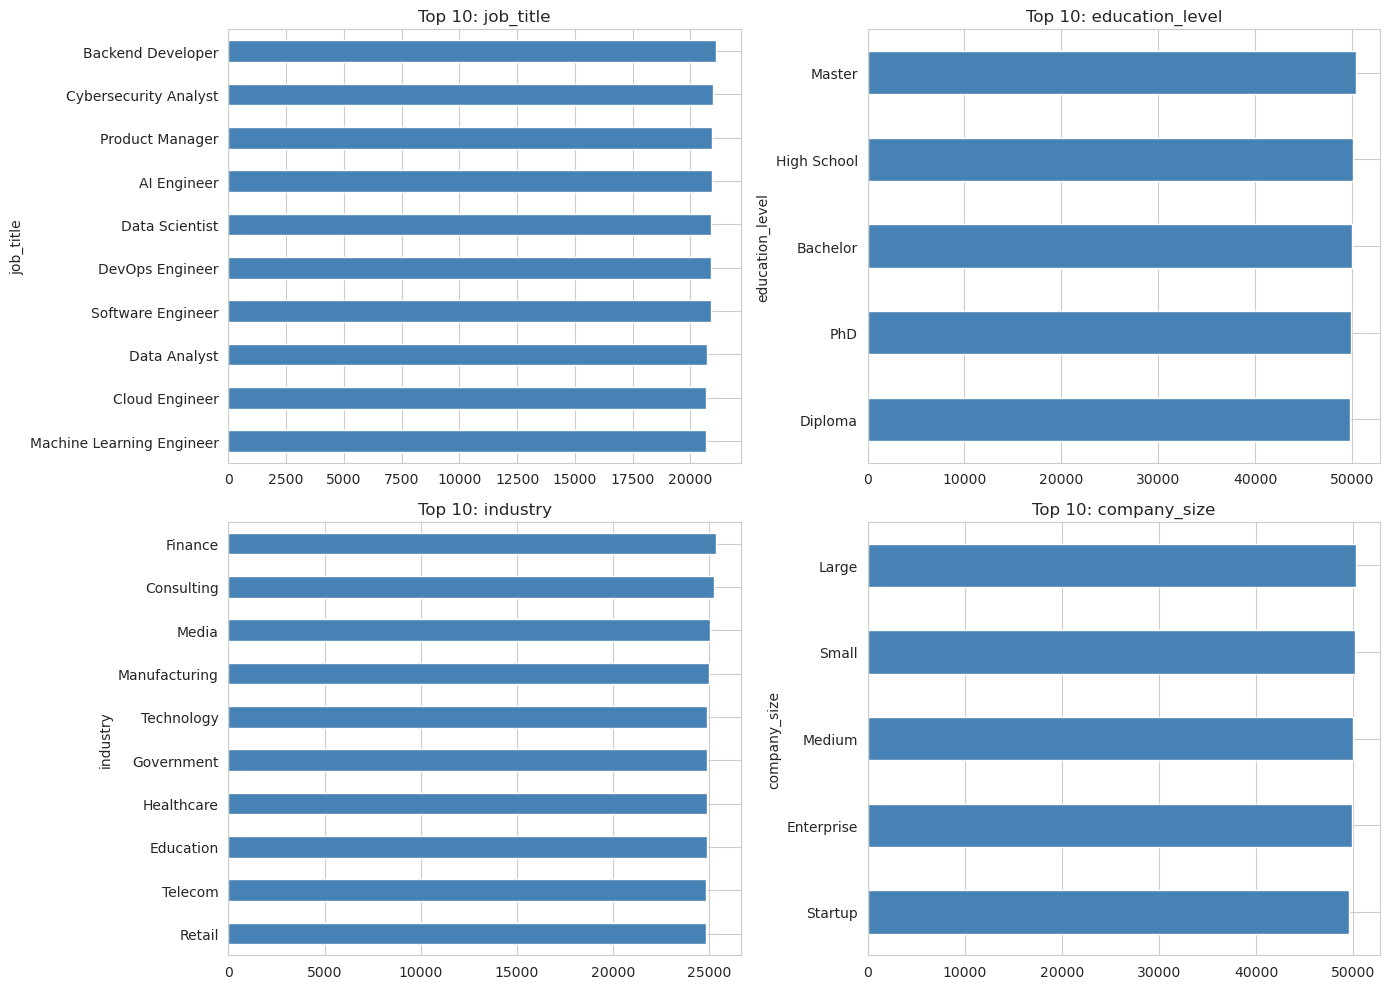

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, cat_cols[:4]):
    df[col].value_counts().head(10).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 10: {col}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()   

Cell 5: Numerical Features vs Salary

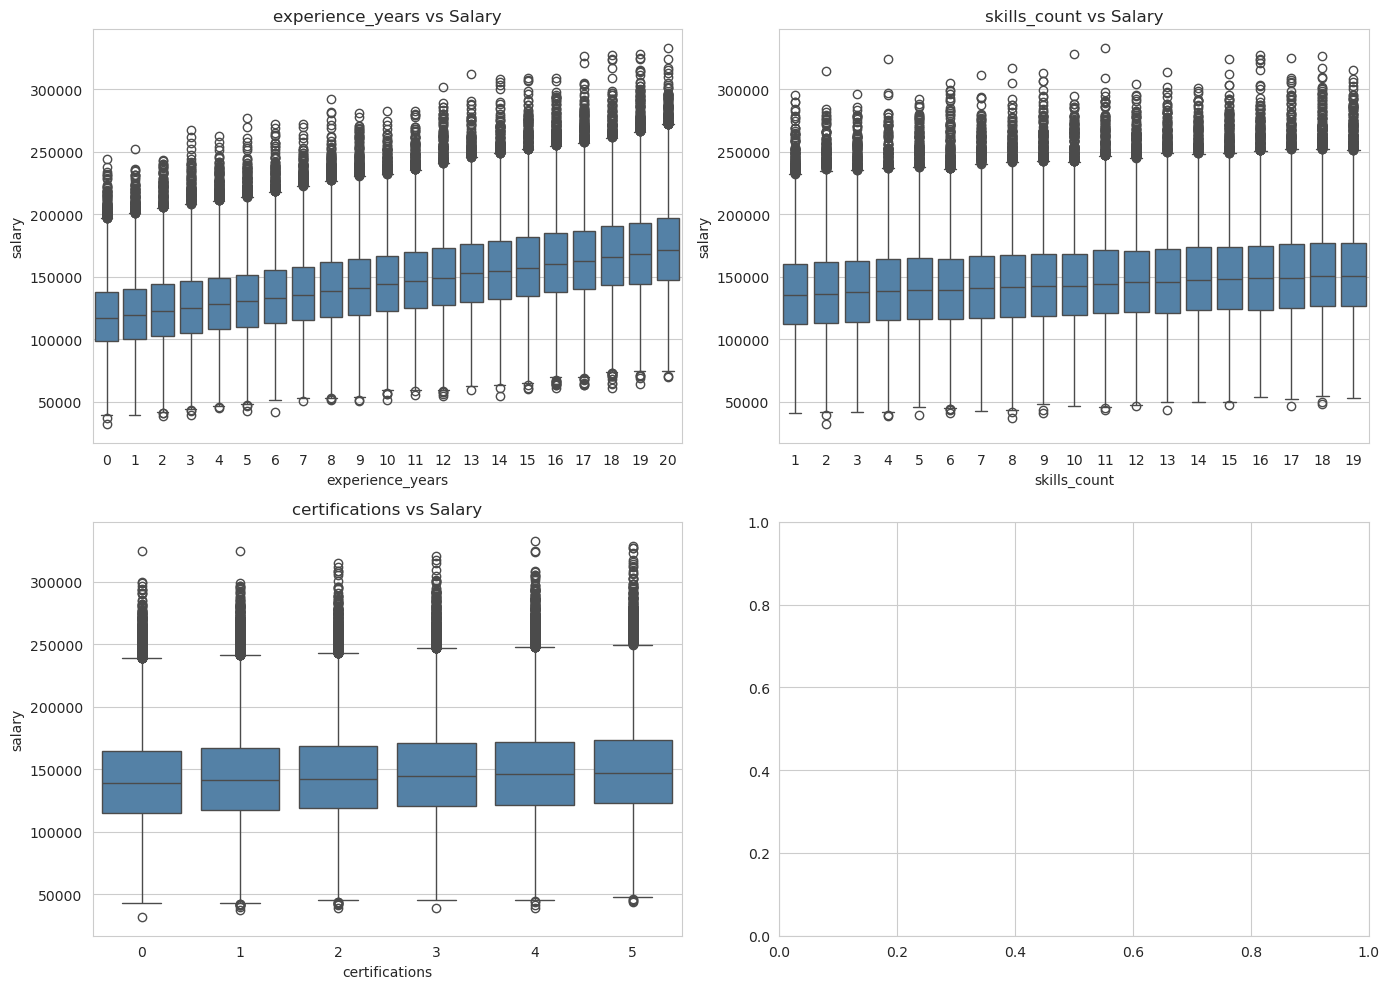

In [9]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['salary', 'salary_log']]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, num_cols[:4]):
    sns.boxplot(data=df, x=col, y='salary', ax=ax, color='steelblue')
    ax.set_title(f'{col} vs Salary')

plt.tight_layout()
plt.show()   

Cell 6: Correlation Heatmap

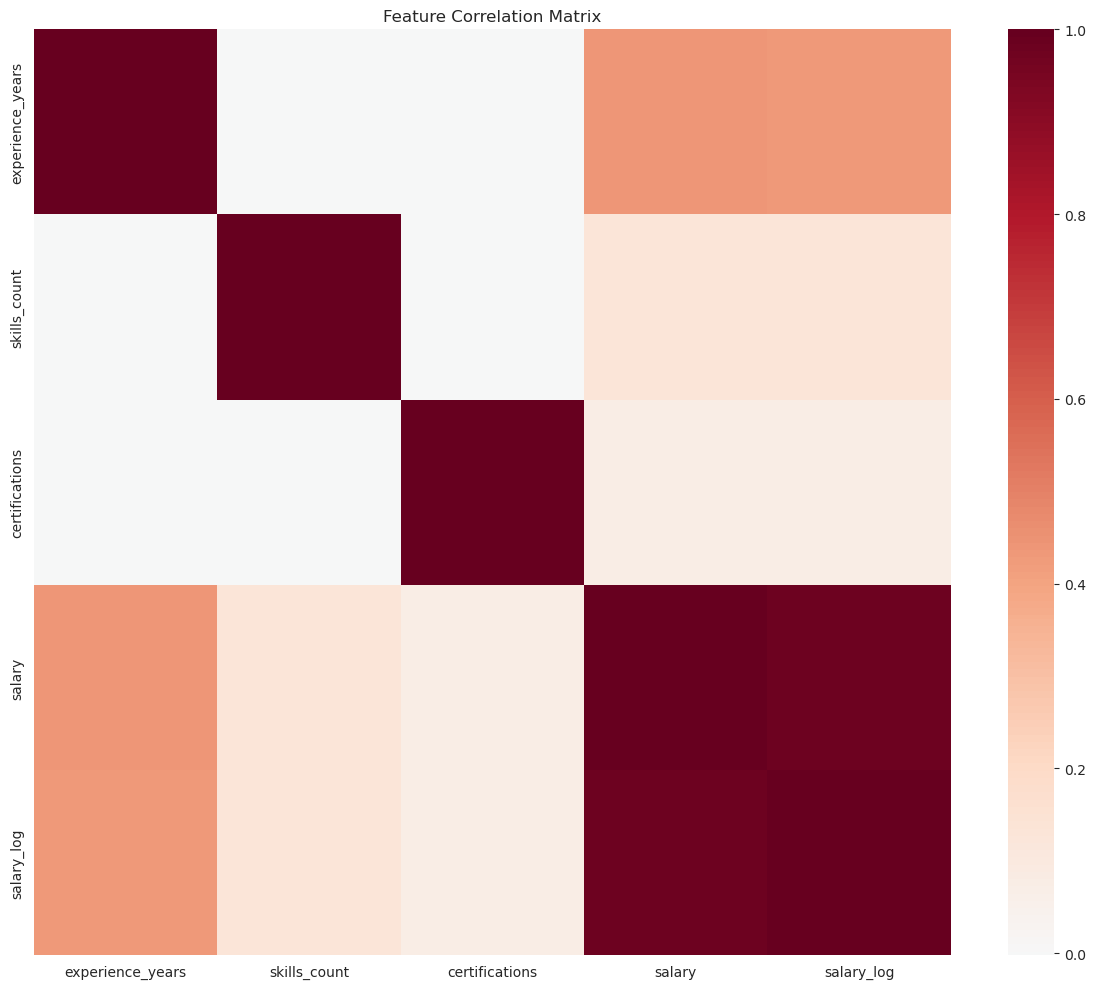

In [10]:
# Encode categoricals temporarily for correlation
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
num_for_corr = df_encoded.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded[num_for_corr].corr(), annot=False, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()   

Cell 7: Quick Model Comparison

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Identify feature types
cat_features = df.select_dtypes(include='object').columns.tolist()
num_features = df.select_dtypes(include='number').columns.tolist()
num_features = [c for c in num_features if c not in ['salary', 'salary_log']]

# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_features)
])

X = df.drop('salary', axis=1).drop(columns=['salary_log'], errors='ignore')
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results[name] = {
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    }
    print(f"{name:25s} | R²={results[name]['R²']:.4f} | MAE=${results[name]['MAE']:,.0f} | RMSE=${results[name]['RMSE']:,.0f}")

# Summary table
results_df = pd.DataFrame(results).T
print(f"\n{'='*60}")
print(results_df.to_string())   

Linear Regression         | R²=0.9635 | MAE=$5,436 | RMSE=$7,126
Random Forest             | R²=0.9713 | MAE=$5,015 | RMSE=$6,320
Gradient Boosting         | R²=0.9493 | MAE=$6,595 | RMSE=$8,392

                         R²          MAE         RMSE
Linear Regression  0.963469  5436.096937  7125.522904
Random Forest      0.971264  5015.342922  6319.705862
Gradient Boosting  0.949327  6595.432406  8392.192703


Cell 8: Feature Importance (from the best model)

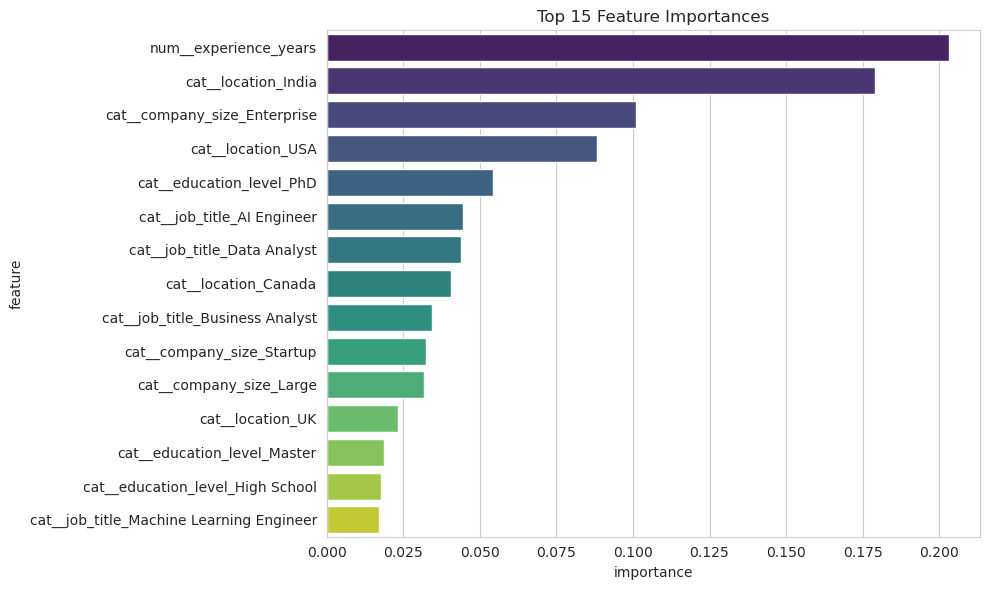

In [12]:
# Use the best model (e.g., Gradient Boosting)
best_pipe = Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))])
best_pipe.fit(X_train, y_train)

# Get feature names (after OneHot encoding)
feature_names = best_pipe.named_steps['prep'].get_feature_names_out()
importances = best_pipe.named_steps['model'].feature_importances_

fi = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi = fi.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()   

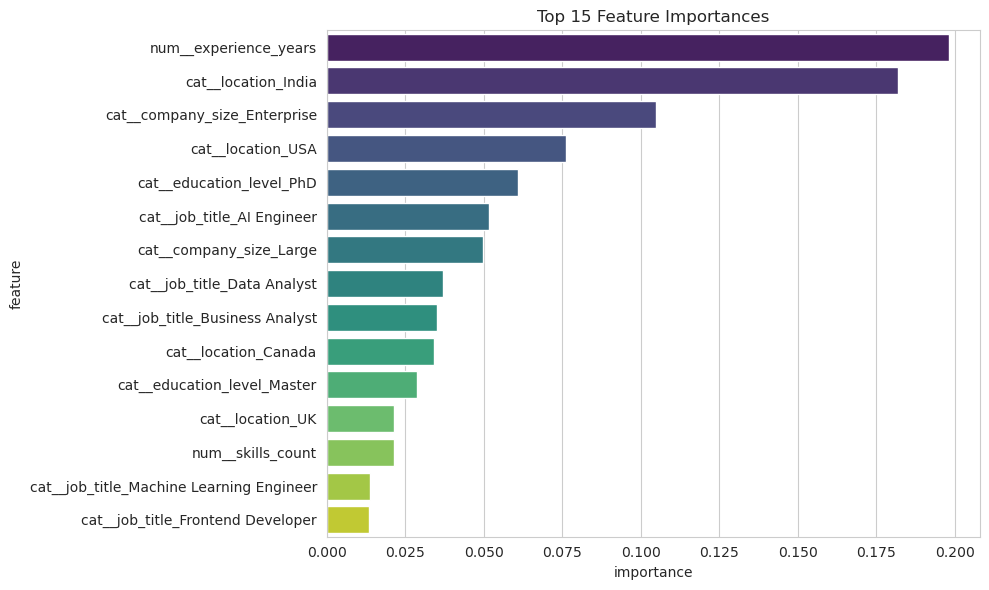

In [13]:
# Use the best model (Random Forest)
best_pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
best_pipe.fit(X_train, y_train)

# Get feature names (after OneHot encoding)
feature_names = best_pipe.named_steps['prep'].get_feature_names_out()
importances = best_pipe.named_steps['model'].feature_importances_

fi = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi = fi.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()   